![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Importación librerías
import numpy as np
import keras 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import tensorflow as tf
from keras import backend as K
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.callbacks import EarlyStopping
from livelossplot import PlotLossesKeras
from keras.layers import Activation

In [3]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
data.describe()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


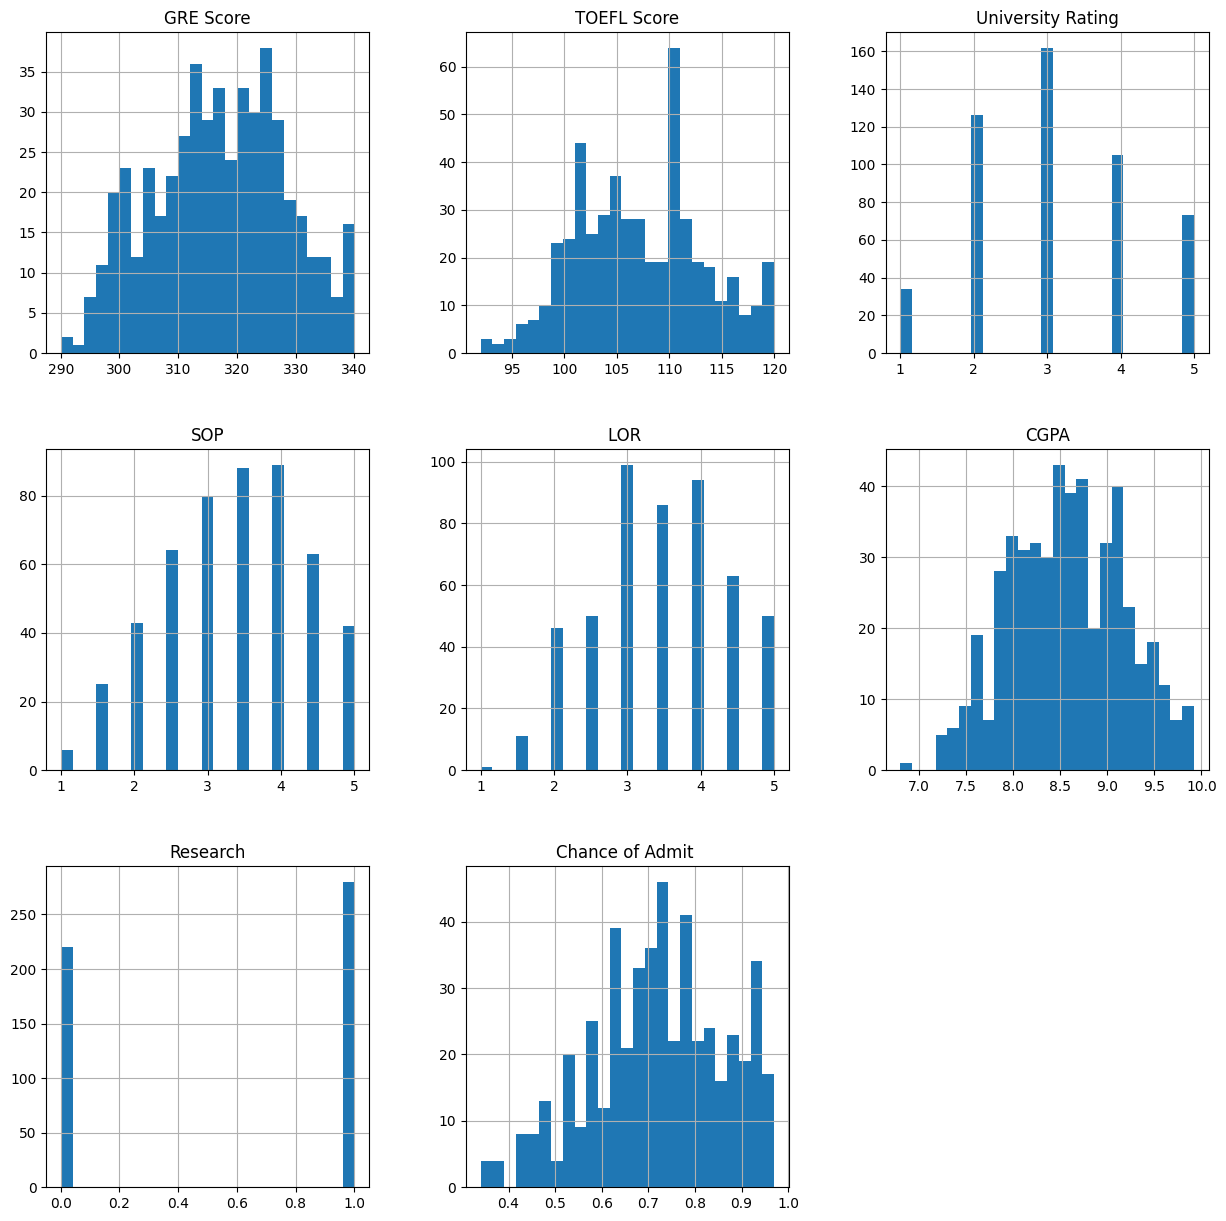

In [5]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [6]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [7]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)

In [8]:
# Normalización de variables predictoras (X) con la función StandardScaler
# Definición de la función StandardScaler
scaler = StandardScaler()
scaler.fit(X)

# Transformación de los set de entrenamiento y test
xTrain = pd.DataFrame(data=scaler.transform(xTrain), columns=xTrain.columns, index=xTrain.index)
xTest = pd.DataFrame(data=scaler.transform(xTest), columns=xTest.columns, index=xTest.index)

xTrain = np.array(xTrain)
yTrain = np.array(yTrain).reshape(-1,1)

xTest = np.array(xTest)
yTest = np.array(yTest).reshape(-1,1)

## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [9]:
# Celda 1
output_var = yTrain.shape[1]
dims = xTrain.shape[1]
K.clear_session()
model = Sequential()
model.add(Dense(output_var, input_shape=(dims,)))
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [10]:
# Definición de función de perdida. Se usa mean_squared_error dado que es un ejercicio de regresión
model.compile(optimizer='sgd', loss='mean_squared_error')

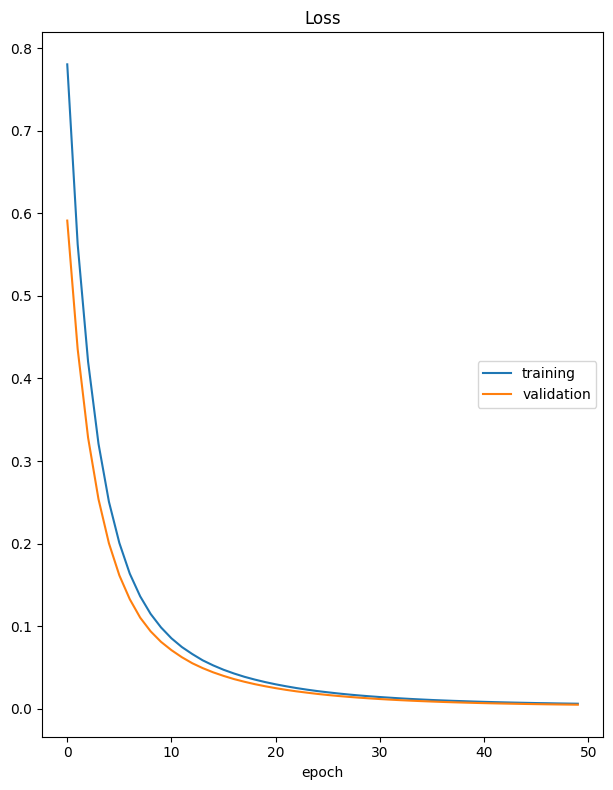

Loss
	training         	 (min:    0.006, max:    0.781, cur:    0.006)
	validation       	 (min:    0.005, max:    0.591, cur:    0.005)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0067 - val_loss: 0.0047


In [11]:
model.fit(xTrain, yTrain, 
          verbose=1, 
          epochs=50, 
          validation_data=(xTest, yTest),
          callbacks=[PlotLossesKeras()])

### Selección de hiperparametros:

- Función de pérdida: debido a la ausencia de valores atípicos que puedan afectar el modelo, así como la búsqueda de penalización de errores grandes, se elige como función de pérdida el 'mean_squared_error'
- Optimizador: Debido a su buen desempeño en modelos menos complejos y su eficiencia en términos computacionales, se decide trabajar con el optimizados sgd.
- Número de Epocas: Debido al comportamiento de la función de pérdida para 50 épocas, se concluye que son suficientes para entender la convergencia del modelo

In [12]:
y_pred = model.predict(xTest)
mse_una_capa = mean_squared_error(yTest, y_pred)
mae_una_capa = mean_absolute_error(yTest, y_pred)

print(f'Mean Squared Error (MSE) red neuronal de una capa: {mse_una_capa}')
print(f'Mean Absolute Error (MAE) red neuronal de una capa: {mae_una_capa}')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Mean Squared Error (MSE) red neuronal de una capa: 0.004748248280511874
Mean Absolute Error (MAE) red neuronal de una capa: 0.051824569996198014


## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [25]:
# Celda 2
# Definición de dimensiones de salida, varaibles de interés
output_var = yTrain.shape[1]
print(output_var, ' output variables')

# Definición de dimensiones de entrada, varaibles predictoras
dims = xTrain.shape[1]
print(dims, 'input variables')

1  output variables
7 input variables


In [47]:
K.clear_session()

# Definición red neuronal con la función Sequential()
model = Sequential()
model.add(Dense(64, input_shape=(dims,), activation='relu'))
model.add(Dense(64, activation='relu'))          
model.add(Dense(output_var))
model.add(Activation('relu'))


# Impresión de la arquitectura de la red neuronal
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

None


In [48]:
# Definición de la función de optimización
model.compile(optimizer='sgd',
              loss='mean_squared_error')

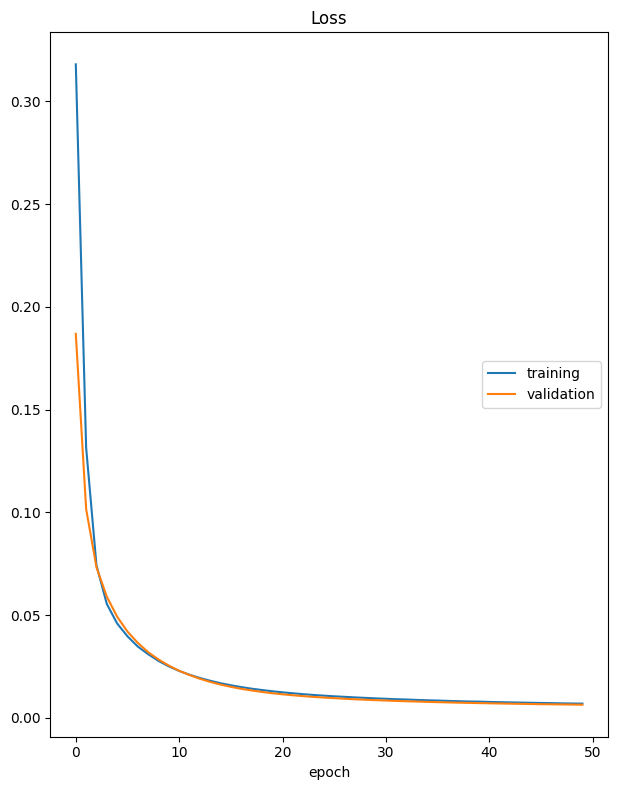

Loss
	training         	 (min:    0.007, max:    0.318, cur:    0.007)
	validation       	 (min:    0.006, max:    0.187, cur:    0.006)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0071 - val_loss: 0.0065


In [49]:
# Entrenamiento de la red neuronal con 50 épocas
model.fit(xTrain, yTrain, 
          verbose=1, 
          epochs=50, 
          validation_data=(xTest, yTest),
          callbacks=[PlotLossesKeras()])

- Función de pérdida: debido a la ausencia de valores atípicos que puedan afectar el modelo, así como la búsqueda de penalización de errores grandes, se elige como función de pérdida el 'mean_squared_error'
- Función de activación: Se selecciona Relu ya que comparada a las funciones tanh(x) y sigmodiea es mucha más fácil de procesar.
- Optimizador: Debido a su buen desempeño en modelos menos complejos y su eficiencia en términos computacionales, se decide trabajar con el optimizador sgd.
- Número de Epocas: Debido al comportamiento de la función de pérdida para 50 épocas, se concluye que son suficientes para entender la convergencia del modelo
- Número de neuronas en las capas: Para este caso en particular, se usaron 64 neuronas en cada capa para no complejisar el modelo si necesidad sabiendo que se está obteniendo muy buen resultado en el mse

In [50]:
yPredTrain = model.predict(xTrain)
yPredTest  = model.predict(xTest)

mae_multicapa_train = mean_absolute_error(yTrain, yPredTrain)
mse_multicapa_train = mean_squared_error(yTrain, yPredTrain)

mae_multicapa_test  = mean_absolute_error(yTest,  yPredTest)
mse_multicapa_test  = mean_squared_error(yTest,  yPredTest)

# Impresión en el formato solicitado
print(f'Mean Squared Error (MSE) red neuronal multicapa (TRAIN): {mse_multicapa_train:.4f}')
print(f'Mean Absolute Error (MAE) red neuronal multicapa (TRAIN): {mae_multicapa_train:.4f}')
print(f'Mean Squared Error (MSE) red neuronal multicapa (TEST): {mse_multicapa_test:.4f}')
print(f'Mean Absolute Error (MAE) red neuronal multicapa (TEST): {mae_multicapa_test:.4f}')

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Mean Squared Error (MSE) red neuronal multicapa (TRAIN): 0.0069
Mean Absolute Error (MAE) red neuronal multicapa (TRAIN): 0.0651
Mean Squared Error (MSE) red neuronal multicapa (TEST): 0.0065
Mean Absolute Error (MAE) red neuronal multicapa (TEST): 0.0645


## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [11]:
# Celda 3
K.clear_session()

model = Sequential()
model.add(Dense(256, activation='relu', input_shape=(xTrain.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 68,097 (266.00 KB)

 Trainable params: 68,097 (266.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [36]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop=EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [37]:
X_train, X_val, Y_train, Y_val = train_test_split(xTrain, yTrain, test_size=0.15, random_state=42)

In [38]:
modelo=model.fit(X_train, Y_train,
          validation_data=(X_val, Y_val),
          epochs=50,
          callbacks=[early_stop])
modelo

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0031 - mae: 0.0422 - val_loss: 0.0032 - val_mae: 0.0424
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0032 - mae: 0.0424 - val_loss: 0.0033 - val_mae: 0.0401
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0033 - mae: 0.0431 - val_loss: 0.0032 - val_mae: 0.0398
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0031 - mae: 0.0410 - val_loss: 0.0032 - val_mae: 0.0389
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0031 - mae: 0.0402 - val_loss: 0.0031 - val_mae: 0.0391
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0029 - mae: 0.0404 - val_loss: 0.0031 - val_mae: 0.0403
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0028 - mae: 0.0403 - val_loss: 0.0032 - val_mae: 0.0399
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0027 - mae: 0.0391 - val_loss: 0.0033 - val_mae: 0.0403
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0030 - mae

Se ha decidido poner dos capas densas, con lo requerido del dropout y el early stop, el cual tiene un tiempo de espera donde el modelo no mejora de 10, ya que con 2, como se planteó en el laboratorio, este se detenía muy rápido sin casi mostrar las épocas. Por consiguiente, se configuró así para alargar las épocas mostradas y que posteriormente en la gráfica se visualizará mejor. De igual manera, no se usó 'relu' en la capa de salida, ya que esta es más adecuada para resultados de 0 a infinito, mientras que 'sigmoid' es mejor para valores acotados entre 0 y 1.

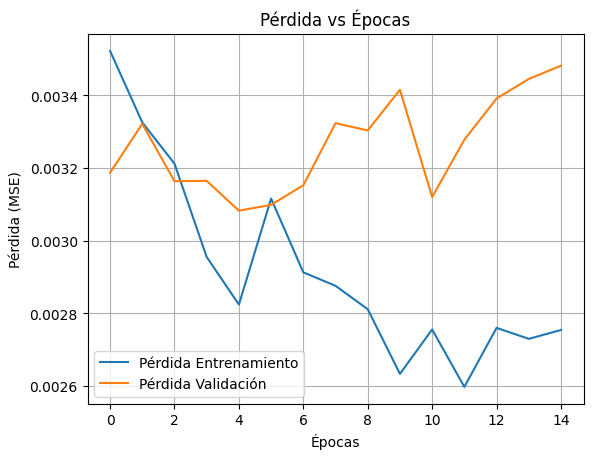

In [39]:
plt.plot(modelo.history['loss'], label='Pérdida Entrenamiento')
plt.plot(modelo.history['val_loss'], label='Pérdida Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.title('Pérdida vs Épocas')
plt.legend()
plt.grid(True)
plt.show()

El modelo muestra como va aprendiendo de los datos hasta la epoca número 4, despúes de eso, se puede evidenciar como la línea de validación aumenta, lo que significa que se comienza a presentar un overfitting en los datos.

In [43]:
y_pred=model.predict(X_val).flatten()

mae=mean_absolute_error(Y_val, y_pred)
mse=mean_squared_error(Y_val, y_pred)

print("MAE: ", mae)
print("MSE: ", mse)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
MAE:  0.03906063754603548
MSE:  0.0030827117707355094


Los valores del MSE y MAE, son bastante bajas, por lo que el modelo está haciendo predicciones bastante acercadas a los valores reales.

## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [ ]:
# Celda 4
